# Mechanism check: does IMFslope respond like the AGN channel or the wind channel?

**Claim under test.** The mediated-through-AGN chain (shallower IMF → more massive
stars → larger BH seeds/growth → AGN-like ejection) predicts that the *morphology* of
IMFslope's one-parameter response should track `BlackHoleRadiativeEfficiency`, not
`VariableWindVelFactor`. Amplitude is the confound — a weak AGN-like response and a
strong wind-like response can have similar raw sizes — so every curve is
**shape-normalized to unit peak**; shape is the fingerprint.

**Honesty note (carried into the caption).** The chain predicts *partial* resemblance:
the IMF also couples directly to the winds through the SNII rate / mass loading, so mixed
morphology — BH-like in one domain, wind-like in another — is a legitimate and
interesting outcome, not a failure of the check. The figure is designed to show *which
regime it resembles where*, not to force a binary.

**Data** (all cached, nothing regenerated):
- `bind_science/runs/twobound/run_{0000..0059}/paired_stats.npz` — shared-sky (paired)
  1P responses for the WL statistics, 50 ray-trace realizations per run, pair $i$ =
  runs $(2i, 2i{+}1)$ = (low, high) bound of astro param $i$ with all 34 other entries
  fiducial (same `lux` seed as the fiducial ⇒ cosmic variance cancels in the pair).
- `bind_science/runs/twobound/run_NNNN/y_maps.npz` + `bind_science/runs/bind/run_0000/`
  (the shared-sky fiducial) — per-realization $C_\ell^{yy}$ (total column, $z\le2.44$),
  computed here once and cached in `mech_cache/`.

**Statistic per family:** $C_\ell^{\kappa\kappa}$ ($\ell$-domain WL, $z_s=1$),
$N_{\rm pk}(\nu)$ ($\nu$-domain, $z_s=1$), $C_\ell^{yy}$ (gas). The twobound runs store
no $\tau$ maps, so Compton-$y$ is the gas-domain statistic; note it weights gas mass
*times* temperature, i.e. it is the heating-sensitive end of the gas family.

In [1]:
# ── Setup: style, paths, run → parameter mapping ─────────────────────────────
import gc
from pathlib import Path
import numpy as np
import pandas as pd
import sys
sys.path.insert(0, "/mnt/home/mlee1/BIND/papers/_tools")
from paper_style import setup, save, panel_label, COLORS, BAND_ALPHA, TWO_COL_TALL
from param_labels import short_label
setup()
%matplotlib inline
import matplotlib.pyplot as plt

CEPH = Path("/mnt/home/mlee1/ceph")
TB   = CEPH/"bind_science/runs/twobound"
FID  = CEPH/"bind_science/runs/bind/run_0000"   # shared-sky fiducial (paired_stats fid_dir)
assert Path.cwd().name == "01_pipeline", "run this notebook from papers/01_pipeline/"
Path("figs_v2").mkdir(exist_ok=True)
CACHE = Path("mech_cache"); CACHE.mkdir(exist_ok=True)

# native 35-vector parameter names from the packaged SB35 table
names35 = list(pd.read_csv("/mnt/home/mlee1/BIND/src/bind/assets/SB35_param_minmax.csv")["ParamName"])

# twobound pair i = runs (2i, 2i+1); the two bounds differ in EXACTLY one native slot
tbp = np.load(TB/"twobound_params.npy")          # (60, 35) native vectors
pairs = {}                                        # param name -> {runs, bounds}
for i in range(30):
    d = np.where(tbp[2*i] != tbp[2*i + 1])[0]
    assert len(d) == 1, f"pair {i}: expected exactly one varied slot, got {d}"
    j = int(d[0])
    pairs[names35[j]] = dict(runs=(2*i, 2*i + 1),
                             bounds=(float(tbp[2*i, j]), float(tbp[2*i + 1, j])))

FOCAL = ["IMFslope", "BlackHoleRadiativeEfficiency", "VariableWindVelFactor"]
PCOL  = {"IMFslope": "#111111",                        # the curve under test
         "BlackHoleRadiativeEfficiency": COLORS["highlight"],   # AGN channel
         "VariableWindVelFactor": COLORS["bind"]}               # wind channel
for p in FOCAL:
    print(f"{p:30s} runs {pairs[p]['runs']}  bounds {pairs[p]['bounds']}")

IMFslope                       runs (12, 13)  bounds (-2.8, -1.8)
BlackHoleRadiativeEfficiency   runs (40, 41)  bounds (0.05, 0.8)
VariableWindVelFactor          runs (4, 5)  bounds (3.7, 14.8)


## Load the paired 1P responses (all 60 runs, small files)

`paired_stats.npz` per run: `clk_resp` = $C_\ell^{\rm run}/C_\ell^{\rm fid}-1$ per $\ell$
bin, `V2_resp` = Minkowski $V_2$ difference normalized by $\max|V_2^{\rm fid}|$;
each with the paired shared-sky error (`std(run−fid)/√N`, ~10× smaller than marginal).
For the peak counts we do NOT use the stored per-bin `pk_resp`: rare-count $\nu$ bins are
noise-dominated, and the `bind-paired-stats` docstring warns that count statistics must be
band-**integrated** per realization, not averaged per bin. So we rebuild the $\nu$-domain
response on 0.5-wide $\nu$ bands from the stored per-realization count cubes
(`pk_real`, fiducial cube from `paired_perreal_fid.npz`): integrate counts per
realization per band, then take the paired ratio. Bands are kept only where the fiducial
holds ≥ 2 peaks per map.

In [2]:
ZI = 1                                            # working source plane: z_s = 1.0
P = [np.load(TB/f"run_{r:04d}/paired_stats.npz") for r in range(60)]
ell, nu = P[0]["ell"], P[0]["nu"]
n_real = int(P[0]["n_real"])
clk   = np.array([p["clk_resp"][ZI] for p in P]); clk_e = np.array([p["clk_err"][ZI] for p in P])
V2    = np.array([p["V2_resp"][ZI]  for p in P]); V2_e  = np.array([p["V2_err"][ZI]  for p in P])

fidcube = np.load(FID/"paired_perreal_fid.npz")

# nu-domain: band-integrate the per-realization counts (KNU raw bins per band),
# then the paired ratio response per band — the statistically correct reduction
# for rare-event counts (see bind-paired-stats docstring).
KNU = 2                                           # 2 x 0.25-wide bins -> 0.5-wide bands
def _coarse(c):                                   # (..., 68) counts -> (..., nb) sums
    n = (c.shape[-1]//KNU)*KNU
    return c[..., :n].reshape(*c.shape[:-1], n//KNU, KNU).sum(-1)
nuc  = nu[:(len(nu)//KNU)*KNU].reshape(-1, KNU).mean(-1)
fidc = _coarse(fidcube["pk"][:, ZI])              # (50, nb) fiducial counts per band
def _pk_resp(p):
    rc = _coarse(p["pk_real"][:, ZI].astype(float))
    n = min(len(rc), len(fidc))
    fm = fidc[:n].mean(0); ok = fm > 0
    resp, err = np.zeros(len(fm)), np.zeros(len(fm))
    resp[ok] = (rc[:n].mean(0)[ok] - fm[ok])/fm[ok]
    err[ok]  = (rc[:n] - fidc[:n]).std(0)[ok]/np.sqrt(n)/fm[ok]
    return resp, err
pk, pk_e = map(np.array, zip(*[_pk_resp(p) for p in P]))

NU_MASK  = fidc.mean(0) >= 2.0                    # >= 2 peaks per map per band
ELL_MASK = (ell >= 100) & (ell <= 2e4)            # ratio statistics cancel the CIC upturn
zs = float(np.load(TB/"run_0000/kappa_maps.npz")["source_redshifts"][ZI])
print(f"n_real={n_real}, z_s={zs:g}; nu bands kept {NU_MASK.sum()}/{len(nuc)} "
      f"(nu in [{nuc[NU_MASK][0]:.2f}, {nuc[NU_MASK][-1]:.2f}]), "
      f"ell bins kept {ELL_MASK.sum()}/{len(ell)}")

n_real=50, z_s=1; nu bands kept 15/34 (nu in [-1.25, 5.75]), ell bins kept 276/724


## Bound choice and parameter ranking

Each parameter has two 1P bounds; shape normalization makes the curves comparable
either way, but the bound with the larger response carries the better paired S/N, so
**per parameter we use the bound with the larger WL-side response amplitude** (RMS of the
block-standardized concatenated $C_\ell^{\kappa\kappa}$ + $N_{\rm pk}$ + $V_2$ vector).
The same amplitude ranks the 30 parameters to pick the similarity-matrix set.

In [3]:
# block-standardized concatenated WL response vector per run -> amplitude
s_clk = np.sqrt(np.mean(clk[:, ELL_MASK]**2))
s_pk  = np.sqrt(np.mean(pk[:,  NU_MASK]**2))
s_V2  = np.sqrt(np.mean(V2**2))
Vrun  = np.hstack([clk[:, ELL_MASK]/s_clk, pk[:, NU_MASK]/s_pk, V2/s_V2])
Arun  = np.sqrt(np.mean(Vrun**2, axis=1))         # (60,) response amplitude per run

chosen, Apar = {}, {}
for name, info in pairs.items():
    rlo, rhi = info["runs"]
    k = rlo if Arun[rlo] >= Arun[rhi] else rhi
    chosen[name] = k
    Apar[name] = Arun[k]

rank = sorted(Apar, key=Apar.get, reverse=True)
TOPN = 6
MATSET = sorted(set(rank[:TOPN]) | set(FOCAL), key=lambda n: rank.index(n))
print("top params by 1P WL response amplitude (chosen bound marked hi/lo):")
for n in rank[:10]:
    b = "hi" if chosen[n] == pairs[n]["runs"][1] else "lo"
    val = pairs[n]["bounds"][chosen[n] - pairs[n]["runs"][0]]
    star = " *" if n in MATSET else ""
    print(f"  {short_label(n):20s} A={Apar[n]:.2f}  {b} bound = {val:g}{star}")
print(f"matrix set ({len(MATSET)}): {[short_label(n) for n in MATSET]}")

top params by 1P WL response amplitude (chosen bound marked hi/lo):
  BHRadiativeEff       A=4.07  hi bound = 0.8 *
  QuasarThreshold      A=2.47  lo bound = 6.33e-05 *
  IMFslope             A=2.18  lo bound = -2.8 *
  WindEnergy1e51erg    A=1.76  hi bound = 14.4 *
  SeedBlackHoleMass    A=1.61  lo bound = 2.5316e-05 *
  VarWindVelFactor     A=1.57  lo bound = 3.7 *
  BHAccretionFac       A=1.44  lo bound = 0.25
  BHEddingtonFac       A=1.44  lo bound = 0.1
  QuasarThreshPow      A=1.32  lo bound = 0
  VarWindSpecMom       A=1.20  hi bound = 4000
matrix set (6): ['BHRadiativeEff', 'QuasarThreshold', 'IMFslope', 'WindEnergy1e51erg', 'SeedBlackHoleMass', 'VarWindVelFactor']


## $C_\ell^{yy}$ paired responses (computed once, cached)

Per run: load the total-column $y$ maps (index −1, $z\le2.44$; the released convention —
see FIGURE_NUMBERS.md dataset note), take the auto power of each of the 50 realizations
with `bind.inference.stats.power_spectrum` (identical $\ell$ grid to $\kappa$ by
construction: same 5° / 1024² maps), and cache `(50, n_ell)` to `mech_cache/`. The
paired response then follows the exact `bind-paired-stats` convention:
`resp = (mean(run) − mean(fid))/mean(fid)`, `err = std(run − fid)/√N/mean(fid)`.
The printed paired-vs-marginal error ratio is the shared-sky receipt: if the twobound
re-trace really reuses the fiducial `lux` seed, the paired error is far below marginal.

In [4]:
def clyy_perreal(run_dir, tag):
    """(ell, (n_real, n_ell)) full-depth C_ell^yy per realization, cached."""
    c = CACHE/f"clyy_{tag}.npz"
    if c.exists():
        d = np.load(c)
        return d["ell"], d["cl"]
    if not (run_dir/"y_maps.npz").exists():
        raise FileNotFoundError(f"{run_dir}/y_maps.npz missing — refusing to guess")
    from bind.inference import stats as S
    y = np.load(run_dir/"y_maps.npz")["y"][:, -1]          # (50, 1024, 1024) total column
    cl, l = [], None
    for r in range(y.shape[0]):
        l, ck = S.power_spectrum(y[r], fov_deg=5.0)
        cl.append(ck)
    del y; gc.collect()
    cl = np.asarray(cl)
    np.savez_compressed(c, ell=l, cl=cl)
    print(f"  cached {c.name}")
    return l, cl

# fiducial + chosen bound of every matrix param + BOTH bounds of the focal three
need = {"fid": FID}
for nme in MATSET:
    need[f"run_{chosen[nme]:04d}"] = TB/f"run_{chosen[nme]:04d}"
for nme in FOCAL:
    for r in pairs[nme]["runs"]:
        need[f"run_{r:04d}"] = TB/f"run_{r:04d}"
print(f"C_ell^yy needed for {len(need)} runs "
      f"({sum(not (CACHE/f'clyy_{t}.npz').exists() for t in need)} to compute) ...")
CLYY = {}
for tag, rd in need.items():
    ell_y, CLYY[tag] = clyy_perreal(rd, tag)
assert np.allclose(ell_y, ell), "yy ell grid != kappa ell grid"

fid_cl = CLYY["fid"]
fm = fid_cl.mean(0)
def yy_resp(tag):
    run_cl = CLYY[tag]
    n = min(len(run_cl), len(fid_cl))
    r, f = run_cl[:n], fid_cl[:n]
    return (r.mean(0) - fm)/fm, (r - f).std(0)/np.sqrt(n)/fm

yy, yy_e = {}, {}
for nme in MATSET:
    yy[nme], yy_e[nme] = yy_resp(f"run_{chosen[nme]:04d}")
# shared-sky receipt at ell ~ 1000
i0 = np.argmin(np.abs(ell - 1e3))
tag0 = f"run_{chosen['IMFslope']:04d}"
marg = CLYY[tag0][:, i0].std()/np.sqrt(len(fid_cl))/fm[i0]
paired = (CLYY[tag0][:, i0] - fid_cl[:, i0]).std()/np.sqrt(len(fid_cl))/fm[i0]
print(f"shared-sky receipt (IMFslope run, ell~1000): paired err {paired*100:.2f}% "
      f"vs marginal {marg*100:.2f}% ({marg/paired:.0f}x reduction)")

C_ell^yy needed for 10 runs (0 to compute) ...
shared-sky receipt (IMFslope run, ell~1000): paired err 1.54% vs marginal 6.76% (4x reduction)


## Similarity matrix

One vector per parameter: the concatenation of all four statistic blocks
($C_\ell^{\kappa\kappa}$ and $C_\ell^{yy}$ log-binned to ~20 bins so no block dominates
by bin count, band-integrated $N_{\rm pk}$ on the populated $0.5$-wide $\nu$ bands,
$V_2(\nu)$), each block divided
by its RMS over the matrix set (a *shared* per-block scale — it equalizes the blocks
without touching relative amplitudes inside a block), then **sign-aligned so each
parameter's own peak is positive** (shape-up-to-sign similarity, matching the
peak-normalization of the curves; low/high bounds of one parameter are near-mirror
vectors, so the check must not depend on which bound was picked). The matrix entry is
the Pearson correlation between two parameters' vectors. Rows are grouped
wind family → IMF/other → AGN family, so "IMFslope clusters with the BH block"
is readable at a glance.

In [5]:
NBIN = 20
EDGES = np.geomspace(100.0, 2e4, NBIN + 1)

def logbin(y, e):
    """Log-ell bin a response curve (mean) and its paired error (quadrature/n)."""
    ib = np.digitize(ell, EDGES) - 1
    L, Y, E = [], [], []
    for b in range(NBIN):
        s = ib == b
        if not s.any():
            continue
        L.append(np.exp(np.log(ell[s]).mean()))
        Y.append(y[s].mean())
        E.append(np.sqrt((e[s]**2).sum())/s.sum())
    return np.array(L), np.array(Y), np.array(E)

def family(name):
    if any(k in name for k in ("BlackHole", "Quasar", "Radio")):
        return "agn"
    if "Wind" in name or "SN" in name:
        return "wind"
    return "other"

FAMCOL = {"wind": COLORS["bind"], "agn": COLORS["highlight"], "other": "#555555"}
ORDER = ([n for n in MATSET if family(n) == "wind"]
         + [n for n in MATSET if family(n) == "other"]
         + [n for n in MATSET if family(n) == "agn"])

# per-param blocks (chosen bound), binned where spectra
blocks = {}
for nme in ORDER:
    k = chosen[nme]
    _, bclk, _ = logbin(clk[k], clk_e[k])
    _, byy, _  = logbin(yy[nme], yy_e[nme])
    blocks[nme] = [bclk, pk[k, NU_MASK], V2[k], byy]

nb = [len(b) for b in blocks[ORDER[0]]]
scale = [np.sqrt(np.mean([blocks[n][j]**2 for n in ORDER])) for j in range(4)]
vec = {}
for nme in ORDER:
    v = np.hstack([blocks[nme][j]/scale[j] for j in range(4)])
    vec[nme] = v * np.sign(v[np.argmax(np.abs(v))])        # own peak positive
M = np.corrcoef([vec[n] for n in ORDER])

BLOCKN = ["$C_\\ell^{\\kappa\\kappa}$", "$N_{\\rm pk}(\\nu)$", "$V_2(\\nu)$", "$C_\\ell^{yy}$"]
print(f"blocks (bins): {dict(zip(BLOCKN, nb))}")

def _align(v):
    """Sign-align a vector so its own peak-|.| entry is positive."""
    return v * np.sign(v[np.argmax(np.abs(v))])

# per-block receipt, aligned PER BLOCK (each curve to its own peak in that
# statistic) — identical convention to the panel stamps. The matrix instead
# aligns the full concatenated vector once (one global sign per parameter),
# so a per-block r and the matrix entry can legitimately differ in sign.
def block_r(a, b, j):
    return np.corrcoef(_align(blocks[a][j]), _align(blocks[b][j]))[0, 1]
print("\nIMFslope shape correlation per statistic (per-block alignment = panel stamps):")
for other in ["BlackHoleRadiativeEfficiency", "VariableWindVelFactor"]:
    rs = [block_r("IMFslope", other, j) for j in range(4)]
    tot = np.corrcoef(vec["IMFslope"], vec[other])[0, 1]
    print(f"  vs {short_label(other):18s} " +
          "  ".join(f"{n}: {r:+.2f}" for n, r in zip(BLOCKN, rs)) +
          f"   concat (matrix): {tot:+.2f}")

blocks (bins): {'$C_\\ell^{\\kappa\\kappa}$': 18, '$N_{\\rm pk}(\\nu)$': 15, '$V_2(\\nu)$': 29, '$C_\\ell^{yy}$': 18}

IMFslope shape correlation per statistic (per-block alignment = panel stamps):
  vs BHRadiativeEff     $C_\ell^{\kappa\kappa}$: +0.99  $N_{\rm pk}(\nu)$: +0.44  $V_2(\nu)$: +1.00  $C_\ell^{yy}$: +0.97   concat (matrix): +0.94
  vs VarWindVelFactor   $C_\ell^{\kappa\kappa}$: +0.78  $N_{\rm pk}(\nu)$: -0.01  $V_2(\nu)$: +0.85  $C_\ell^{yy}$: +0.49   concat (matrix): -0.39


## The figure

Panels (a)–(c): shape-normalized 1P response overlays (each curve divided by its signed
value at its own peak-$|{\cdot}|$ bin, so every curve passes through +1 at its peak; the
legend keeps the raw peak amplitude — the confound we normalized away). Bands are the
paired 50-realization errors, scaled by the same factor. Each panel is stamped with the
shape correlation of IMFslope against the two channels *in that panel's statistic* —
the "which regime does it resemble where" receipt. Panel (d): the concatenated
similarity matrix.

wrote figs_v2/fig21_mechanism_imfslope.pdf (+ preview figs_preview/fig21_mechanism_imfslope.png)


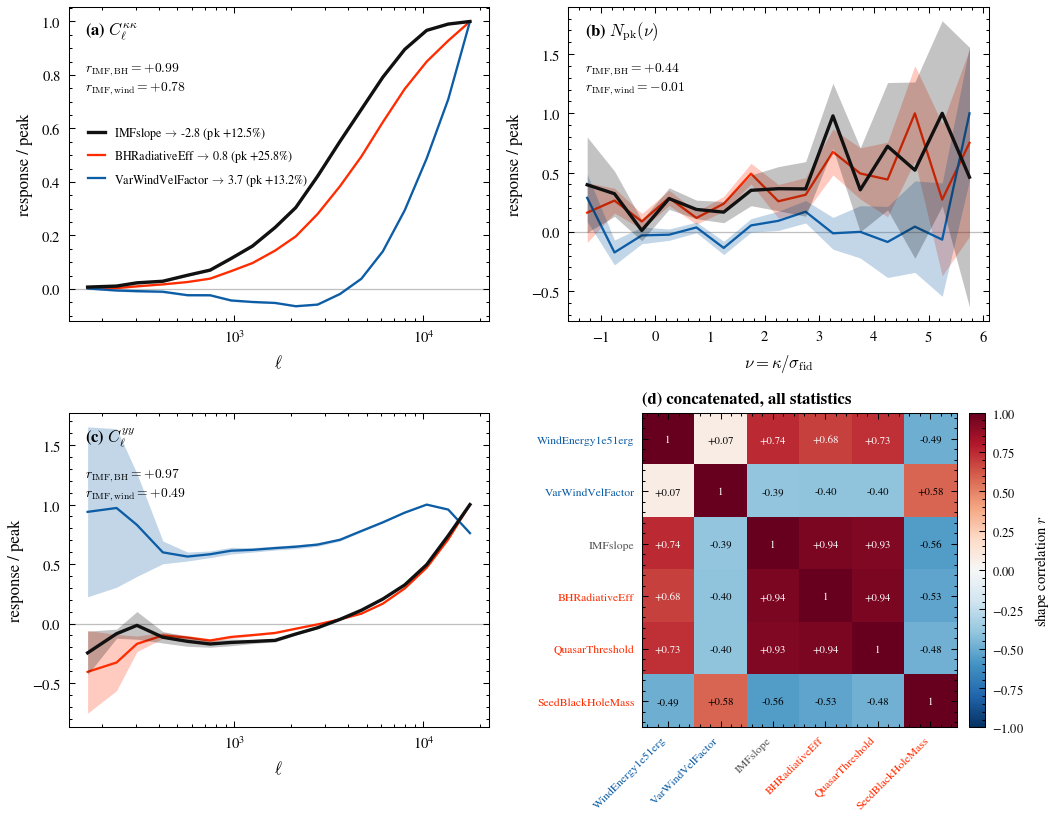

In [6]:
def shapenorm(y, e):
    k = int(np.argmax(np.abs(y)))
    return y/y[k], e/abs(y[k]), y[k]

fig, axes = plt.subplots(2, 2, figsize=TWO_COL_TALL)
(axA, axB), (axC, axD) = axes
panels = [(axA, "(a)", "$C_\\ell^{\\kappa\\kappa}$", 0), (axB, "(b)", "$N_{\\rm pk}(\\nu)$", 1),
          (axC, "(c)", "$C_\\ell^{yy}$", 3)]

curves = {}          # (panel, param) -> normalized curve, for the per-panel r stamps
for ax, tag, bl, j in panels:
    for nme in FOCAL:
        k = chosen[nme]
        if j == 0:
            x, y, e = logbin(clk[k], clk_e[k])
        elif j == 1:
            x, y, e = nuc[NU_MASK], pk[k, NU_MASK], pk_e[k, NU_MASK]
        else:
            x, y, e = logbin(yy[nme], yy_e[nme])
        yn, en, pkamp = shapenorm(y, e)
        curves[(j, nme)] = yn
        val = pairs[nme]["bounds"][k - pairs[nme]["runs"][0]]
        lw = 1.6 if nme == "IMFslope" else 1.1
        z = 5 if nme == "IMFslope" else 3
        lab = f"{short_label(nme)}$\\,\\to\\,${val:g} (pk {pkamp*100:+.1f}%)"
        ax.plot(x, yn, color=PCOL[nme], lw=lw, zorder=z, label=lab)
        ax.fill_between(x, yn - en, yn + en, color=PCOL[nme], alpha=BAND_ALPHA,
                        lw=0, zorder=z - 1)
    if j != 1:
        ax.set_xscale("log")
        ax.set_xlabel(r"$\ell$")
    else:
        ax.set_xlabel(r"$\nu = \kappa/\sigma_{\rm fid}$")
    ax.axhline(0.0, color="0.75", lw=0.6, zorder=1)
    ax.set_ylabel("response / peak")
    rB = np.corrcoef(curves[(j, "IMFslope")],
                     curves[(j, "BlackHoleRadiativeEfficiency")])[0, 1]
    rW = np.corrcoef(curves[(j, "IMFslope")],
                     curves[(j, "VariableWindVelFactor")])[0, 1]
    panel_label(ax, f"{tag} {bl}")
    ax.text(0.04, 0.83, f"$r_{{\\rm IMF,BH}}={rB:+.2f}$\n$r_{{\\rm IMF,wind}}={rW:+.2f}$",
            transform=ax.transAxes, fontsize=6.5, va="top")
    if j == 0:
        # curves rise lower-left -> upper-right; the mid-left band is free
        ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.66), fontsize=5.8,
                  handlelength=1.4)

# (d) similarity matrix
im = axD.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
labs = [short_label(n) for n in ORDER]
axD.set_xticks(range(len(ORDER)))
axD.set_yticks(range(len(ORDER)))
axD.set_xticklabels(labs, rotation=45, ha="right", fontsize=5.6)
axD.set_yticklabels(labs, fontsize=5.6)
for t, nme in zip(axD.get_xticklabels(), ORDER):
    t.set_color(FAMCOL[family(nme)])
for t, nme in zip(axD.get_yticklabels(), ORDER):
    t.set_color(FAMCOL[family(nme)])
for i in range(len(ORDER)):
    for jj in range(len(ORDER)):
        axD.text(jj, i, f"{M[i, jj]:+.2f}".replace("+1.00", "1"), ha="center",
                 va="center", fontsize=5.2,
                 color="w" if abs(M[i, jj]) > 0.6 else "k")
axD.text(0.0, 1.02, "(d) concatenated, all statistics", transform=axD.transAxes,
         fontsize=8, fontweight="bold", va="bottom")
cb = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.03)
cb.set_label("shape correlation $r$", fontsize=7)
cb.ax.tick_params(labelsize=6)
fig.tight_layout()
save(fig, "figs_v2/fig21_mechanism_imfslope")
plt.show()

## Robustness + caption stamps

In [7]:
# does the verdict depend on the IMFslope bound? redo the per-family correlations
# with the OTHER IMF bound (shape only; the yy leg was cached for both bounds)
other_imf = [r for r in pairs["IMFslope"]["runs"] if r != chosen["IMFslope"]][0]
yy_o, yye_o = yy_resp(f"run_{other_imf:04d}")
alt = {}
for j, other in enumerate(["BlackHoleRadiativeEfficiency", "VariableWindVelFactor"]):
    rs = []
    for (blname, jj) in [("clk", 0), ("pk", 1), ("V2", 2), ("yy", 3)]:
        if jj == 0:
            _, a, _ = logbin(clk[other_imf], clk_e[other_imf])
        elif jj == 1:
            a = pk[other_imf, NU_MASK]
        elif jj == 2:
            a = V2[other_imf]
        else:
            _, a, _ = logbin(yy_o, yye_o)
        rs.append(np.corrcoef(_align(a), _align(blocks[other][jj]))[0, 1])
    alt[other] = rs
    print(f"IMFslope ({'hi' if other_imf == pairs['IMFslope']['runs'][1] else 'lo'} bound)"
          f" vs {short_label(other):18s} " +
          "  ".join(f"{n}: {r:+.2f}" for n, r in zip(BLOCKN, rs)))

# matrix row for the caption. NOTE: family MEANS would mislead here — e.g.
# SeedBlackHoleMass at its chosen (low) bound *removes* the AGN channel, so its
# response is anti-aligned with the AGN-strengthening knobs by construction;
# quote the per-parameter row, not a family average.
iI = ORDER.index("IMFslope")
print("\nIMFslope matrix row: " +
      ", ".join(f"{short_label(n)} {M[iI, ORDER.index(n)]:+.2f}" for n in ORDER if n != "IMFslope"))

IMFslope (hi bound) vs BHRadiativeEff     $C_\ell^{\kappa\kappa}$: +0.69  $N_{\rm pk}(\nu)$: +0.27  $V_2(\nu)$: +0.95  $C_\ell^{yy}$: +0.68
IMFslope (hi bound) vs VarWindVelFactor   $C_\ell^{\kappa\kappa}$: +0.25  $N_{\rm pk}(\nu)$: +0.65  $V_2(\nu)$: +0.71  $C_\ell^{yy}$: +0.81

IMFslope matrix row: WindEnergy1e51erg +0.74, VarWindVelFactor -0.39, BHRadiativeEff +0.94, QuasarThreshold +0.93, SeedBlackHoleMass -0.56


## Caption draft

> **Fig. 21 — Is IMFslope's response AGN-shaped or wind-shaped?** (a)–(c) One-parameter
> response of one statistic per family — $C_\ell^{\kappa\kappa}$ and $N_{\rm pk}(\nu)$
> at $z_s=1$, and total-column $C_\ell^{yy}$ — for IMFslope (black), the AGN channel
> `BHRadiativeEff` (red), and the SN-wind channel `VarWindVelFactor` (blue). Each curve
> is the fractional paired response of the stronger 1P bound (bound and raw peak
> amplitude in the legend), **normalized to unit peak** because amplitude is the
> confound and shape the fingerprint; bands are shared-sky errors from the 50 paired
> ray-trace realizations. Each panel is stamped with IMFslope's shape correlation
> against the two channels in that statistic. (d) Shape correlation of the concatenated
> response vector (all four statistic blocks, block-equalized, sign-aligned to each
> parameter's own peak) for the highest-amplitude 1P parameters plus the focal three,
> grouped wind (blue labels) / other (gray) / AGN (red). *The mediated-through-AGN chain
> predicts partial resemblance only: the IMF also feeds the winds directly through the
> SNII rate and mass loading, so mixed morphology — BH-like in one domain, wind-like in
> another — is a physical outcome the panels are designed to localize, not a failure of
> the check.*

Verdict from the executed stamps (quote the printed cells, not this prose, if they
change): at the stronger (steep, $-2.8$) bound IMFslope is AGN-shaped in three of the
four statistics — $r_{\rm IMF,BH} = +0.99$ ($C_\ell^{\kappa\kappa}$), $+1.00$ ($V_2$),
$+0.97$ ($C_\ell^{yy}$) against $+0.78$/$+0.85$/$+0.49$ for the wind channel — and
moderately AGN-shaped in the $\nu$-domain ($+0.44$ vs $-0.01$); the concatenated matrix
places it inside the AGN block ($+0.94$ BHRadiativeEff, $+0.93$ QuasarThreshold, vs
$-0.39$ VarWindVelFactor). The robustness cell shows the predicted *mixed* morphology
surfacing on the top-heavy ($-1.8$) bound: still BH-like in $V_2$ ($+0.95$) and
$C_\ell^{\kappa\kappa}$ ($+0.69$), but wind-like in the gas statistic ($+0.81$ wind vs
$+0.68$ BH) and $N_{\rm pk}$ ($+0.65$ vs $+0.27$) — i.e. steepening the IMF moves the
observables along the AGN axis, while flattening it excites both channels at once.